## STAT3612: Statistical Machine Learning
### Assignment 1: Python basics and logistic regression
### DUE: Feb 16, 2025, Sunday, 11:59 PM

In [1]:
# TODO: please make sure you have Python 3.6+
# please install these packages:
! pip install numpy pandas matplotlib seaborn sklearn umap-learn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
    

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import umap

sns.set_style("darkgrid")

#### Part 1: Conceptual Questions

In [ ]:
# Q1 (a)

# ------------------
# False, because predicting number of customers is a numerical quantity, which is a regression problem. Classification is used when the output is categorical/class label.
# ------------------

# Q1 (b)

# ------------------
# True, because a classifier is defined based on the shape of its decision boundary, and it is consider linear if the decision boundary between classes can be written as a linear equation in the input features
# ------------------

# Q1 (c)

# ------------------
# False, due to bias-variance tradeoff. As MSE depends on both bias and variance, low bias does NOT guarantee that performance of the model is ALWAYS better.
# ------------------

# Q1 (d)

# ------------------
# True.
# ------------------


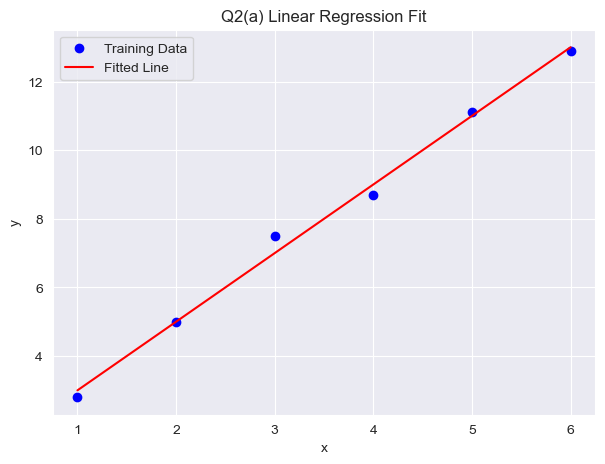

Fitted model: y = 1.0000 + 2.0000 * x


In [3]:
# Q2(a)

# ------------------
# Training data 
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0]) 
y = np.array([2.8, 5.0, 7.5, 8.7, 11.1, 12.9]) 

# Fit linear regression using numpy (slope and intercept) 
theta1, theta0 = np.polyfit(x, y, 1) 

# Predicted y values 
y_pred = theta0 + theta1 * x 

# Plot scatter + regression line 
plt.figure(figsize=(7, 5)) 
plt.scatter(x, y, color='blue', label='Training Data') 
plt.plot(x, y_pred, color='red', label='Fitted Line') 
plt.xlabel("x") 
plt.ylabel("y") 
plt.title("Q2(a) Linear Regression Fit") 
plt.legend() 
plt.show() 

print("Fitted model: y = {:.4f} + {:.4f} * x".format(theta0, theta1))
# ------------------

In [4]:
# Q2(b)

# ------------------
# If I try fitting a 5-th order polynomial to the training data, I will get training error = 0 because with 6 data points and 6 equations, the 5th-order polynomial can always be made to interpolate exactly any 6 points with distinct x-values.
# With a unique polynomial that passes all 6 points, J(theta) = 0 because y_i - y_hat_theta*x_i = 0.
# ------------------

#### Part 2: Python and NumPy basics

In [5]:
file_path = "Employee-Attrition-Classification.csv"
col_names = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents", "Attrition"]

# Q3 (a)  

# ------------------
# Read the CSV file 
df = pd.read_csv(file_path) 

# Keep only the required 8 columns 
col_names = ["Age", "Years at Company", "Monthly Income", "Distance from Home", "Company Tenure", "Number of Promotions", "Number of Dependents", "Attrition"] 
df = df[col_names].copy() 

# Convert Attrition labels: Stayed = 1, Left = 0 
df["Attrition"] = df["Attrition"].map({"Stayed": 1, "Left": 0}) 

df.head()
# ------------------

,Age,Years at Company,Monthly Income,Distance from Home,Company Tenure,Number of Promotions,Number of Dependents,Attrition
0,31,19,5390,22,89,2,0,1
1,59,4,5534,21,21,3,3,1
2,24,10,8159,11,74,0,3,1
3,36,7,3989,27,50,1,2,1
4,56,41,4821,71,68,0,0,1


In [6]:
# Q3 (b)  

attr_names = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents"]

# ------------------
# Compute statistics for the 7 attributes 
stats = df[attr_names].describe().T # transpose for nicer formatting 
stats
# ------------------

,count,mean,std,min,25%,50%,75%,max
Age,59598.0,38.565875,12.079673,18.0,28.0,39.0,49.0,59.0
Years at Company,59598.0,15.753901,11.245981,1.0,7.0,13.0,23.0,51.0
Monthly Income,59598.0,7302.397983,2151.457423,1316.0,5658.0,7354.0,8880.0,16149.0
Distance from Home,59598.0,50.007651,28.466459,1.0,25.0,50.0,75.0,99.0
Company Tenure,59598.0,55.758415,25.411090,2.0,36.0,56.0,76.0,128.0
Number of Promotions,59598.0,0.832578,0.994991,0.0,0.0,1.0,2.0,4.0
Number of Dependents,59598.0,1.648075,1.555689,0.0,0.0,1.0,3.0,6.0


In [7]:
# Q3 (c)  

# ------------------
corr_matrix = df[attr_names].corr(method="pearson") 
corr_matrix
# ------------------

,Age,Years at Company,Monthly Income,Distance from Home,Company Tenure,Number of Promotions,Number of Dependents
Age,1.000000,0.539806,-0.001989,-0.007063,0.237048,0.000167,0.002927
Years at Company,0.539806,1.000000,-0.005288,-0.006888,0.442180,-0.000229,0.003973
Monthly Income,-0.001989,-0.005288,1.000000,-0.002528,-0.005397,0.006418,0.002582
Distance from Home,-0.007063,-0.006888,-0.002528,1.000000,-0.005595,-0.007882,0.000659
Company Tenure,0.237048,0.442180,-0.005397,-0.005595,1.000000,0.003903,0.001600
Number of Promotions,0.000167,-0.000229,0.006418,-0.007882,0.003903,1.000000,-0.000558
Number of Dependents,0.002927,0.003973,0.002582,0.000659,0.001600,-0.000558,1.000000


In [8]:
# Q3 (d)  

attr_names = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents"]

# ------------------
# Standardize the 7 attributes: (x - mean) / std 
X_standardized = (df[attr_names] - df[attr_names].mean()) / df[attr_names].std() 
X_standardized.head()
# ------------------

,Age,Years at Company,Monthly Income,Distance from Home,Company Tenure,Number of Promotions,Number of Dependents
0,-0.626331,0.288645,-0.888885,-0.983883,1.308153,1.173299,-1.059386
1,1.691612,-1.045165,-0.821954,-1.019012,-1.367844,2.178333,0.869020
2,-1.205817,-0.511641,0.398150,-1.370302,0.717859,-0.836770,0.869020
3,-0.212413,-0.778403,-1.540071,-0.808237,-0.226610,0.168265,0.226218
4,1.443261,2.244900,-1.153357,0.737442,0.481742,-0.836770,-1.059386


In [9]:
# Q3 (e)  

# ------------------
# Randomly split into training (80%) and testing (20%) 
train_df = df.sample(frac=0.8, random_state=42) 
test_df = df.drop(train_df.index) 

# Calculating training set mean and std 
train_mean = train_df[attr_names].mean() 
train_std = train_df[attr_names].std() 

# Standarize train and test set using ONLY training set mean and std
train_stdzd = (train_df[attr_names] - train_mean) / train_std 
test_stdzd = (test_df[attr_names] - train_mean) / train_std 

train_stdzd.head()
test_stdzd.head()

# We should not use the standardized results obtained in Q3(d) because those values were computed using the entire dataset, which includes both the training and testing samples. 
# In a real machine‑learning workflow, the testing data must be treated as completely unknown during model training. 
# If we compute the mean and standard deviation using the full dataset, information from the test set would leak into the training process, causing the model to indirectly “see” the test data before evaluation. 
# This data leakage makes the evaluation unreliable because the model’s performance would appear better than it truly is. 
# Therefore, the correct approach is to compute the mean and standard deviation using only the training data and then apply those same scaling parameters to both the training and testing sets. 
# This ensures that the testing phase reflects a genuine scenario where future data is unavailable during training.

# ------------------

,Age,Years at Company,Monthly Income,Distance from Home,Company Tenure,Number of Promotions,Number of Dependents
2,-1.206564,-0.510320,0.400841,-1.367490,0.716689,-0.836061,0.870731
9,-1.206564,-1.311936,0.010748,0.247274,-0.421978,0.168493,1.514180
10,-0.709175,-0.332183,-0.860462,0.036653,-1.521381,0.168493,-0.416168
12,0.700092,1.983599,0.809511,0.984449,0.481103,0.168493,-1.059617
16,-1.621054,-0.599388,0.439386,-1.156868,0.284781,1.173048,0.870731


We should calculate the mean and std only rely on training data, as testing data is considered as not known during training.

#### Part 2: Data visualization

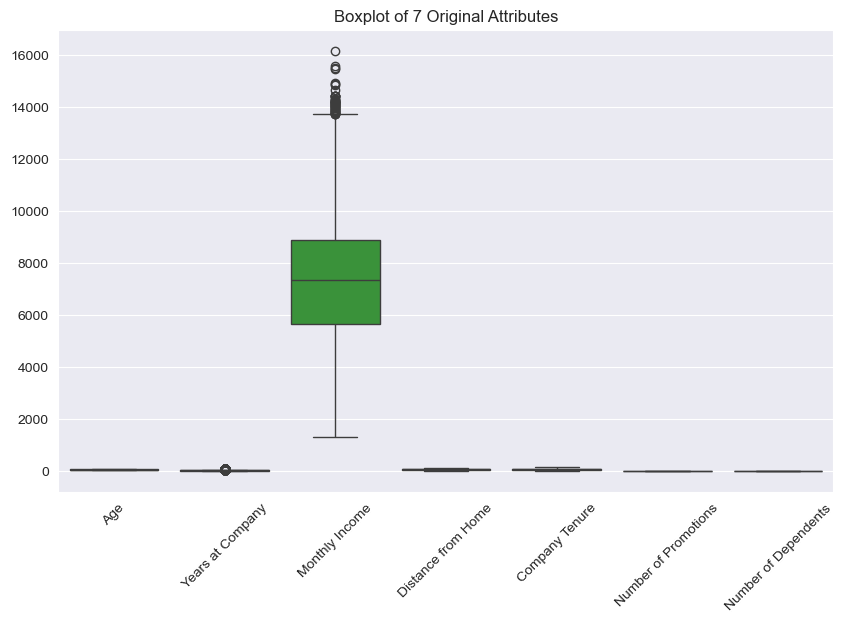

In [10]:
# Q4 (a)  

# ------------------
plt.figure(figsize=(10, 6)) 
sns.boxplot(data=df[attr_names]) 
plt.title("Boxplot of 7 Original Attributes") 
plt.xticks(rotation=45) 
plt.show()
# ------------------

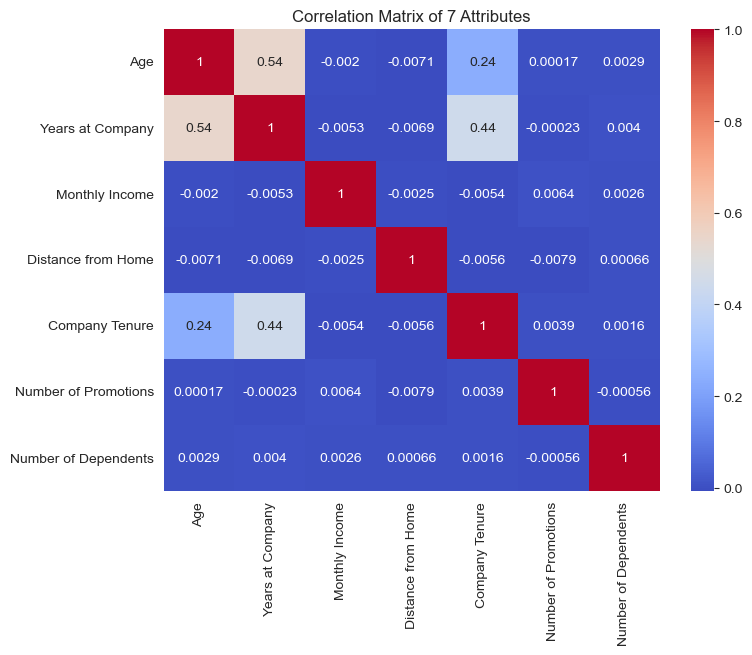

In [12]:
# Q4 (b)
#  -------------------
plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", xticklabels=attr_names, yticklabels=attr_names) 
plt.title("Correlation Matrix of 7 Attributes") 
plt.show()
# -------------------

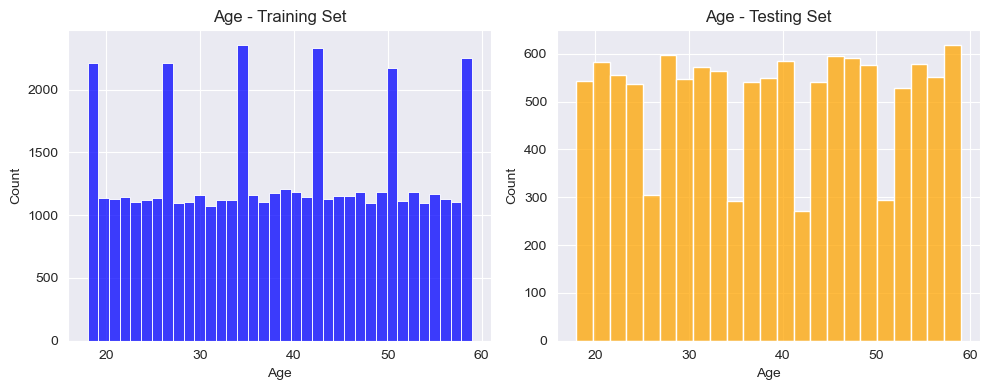

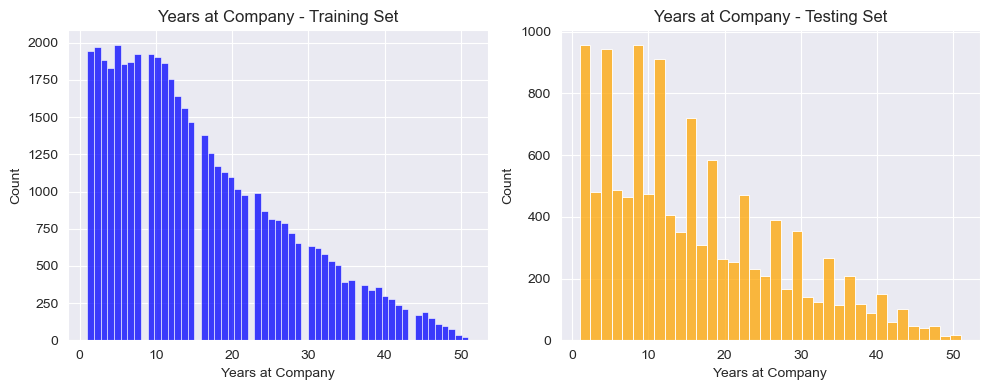

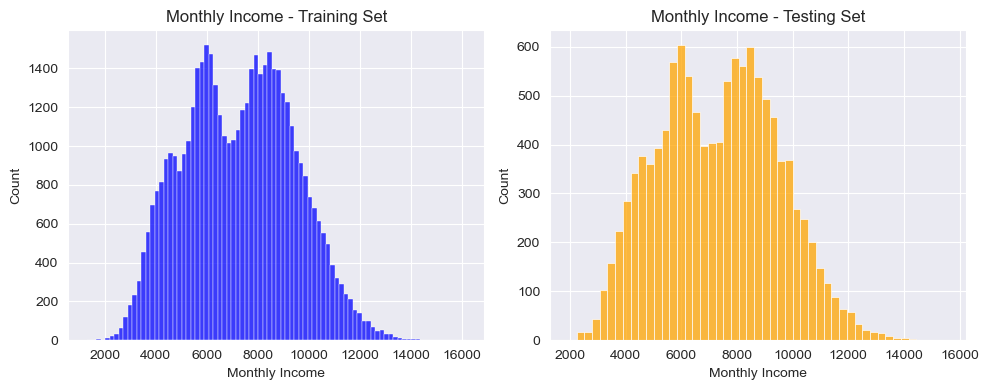

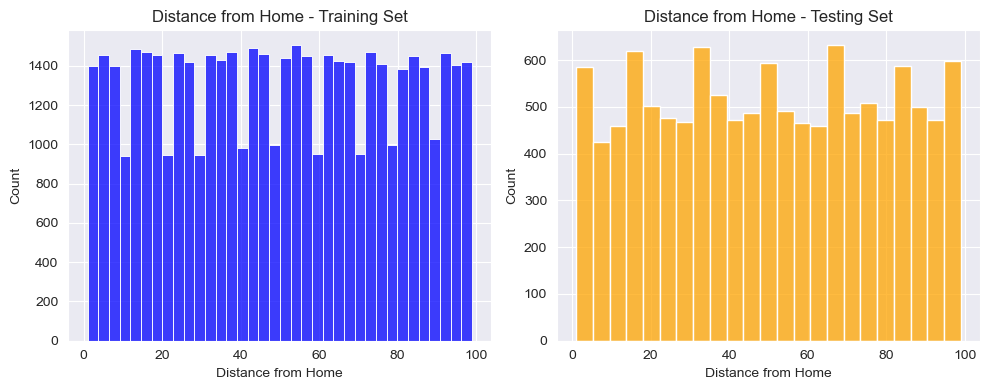

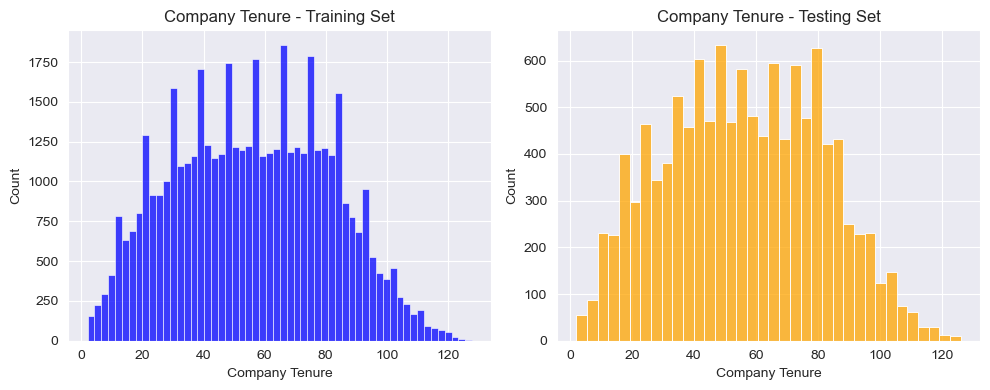

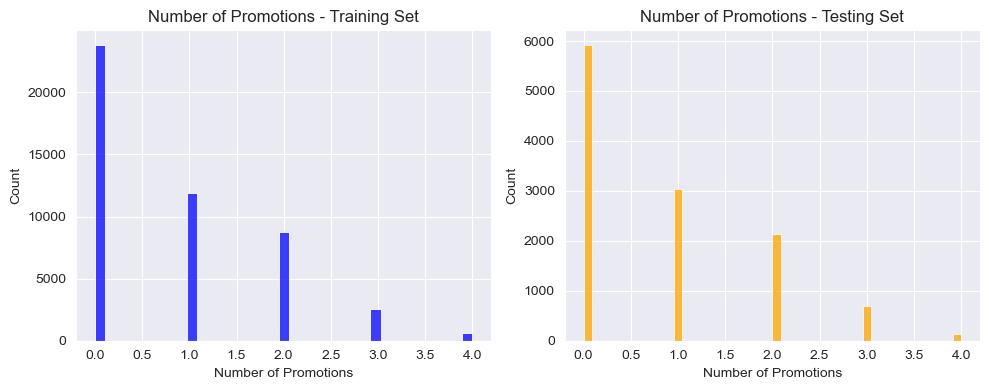

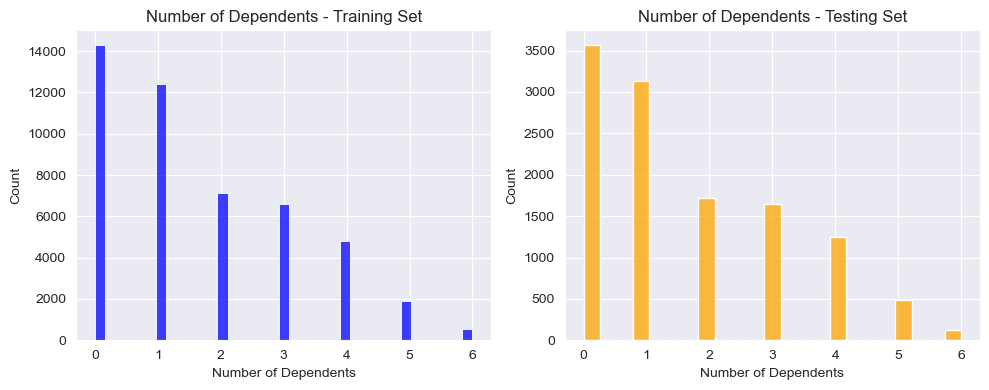

In [11]:
# Q4 (c)
#  -------------------
for attr in attr_names: 
    plt.figure(figsize=(10, 4)) 
    
    # Subplot 1 — Training set 
    plt.subplot(1, 2, 1) 
    sns.histplot(train_df[attr], kde=False, color='blue') 
    plt.title(f"{attr} - Training Set") 
    plt.xlabel(attr) 
    plt.ylabel("Count") 
    
    # Subplot 2 — Testing set 
    plt.subplot(1, 2, 2) 
    sns.histplot(test_df[attr], kde=False, color='orange') 
    plt.title(f"{attr} - Testing Set") 
    plt.xlabel(attr) 
    plt.ylabel("Count") 
    
    plt.tight_layout() 
    plt.show()
#  -------------------

#### Part 3: Logistic regression

In [ ]:
# Q5 (a)

train_columns = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents"]
test_columns = ["Attrition"]

# -------------------
# Prepare training data 
X_train = train_stdzd[train_columns] 
y_train = train_df[test_columns].values.ravel() # flatten to 1D array 

# Fit logistic regression model 
log_reg = LogisticRegression(max_iter=1000) 
log_reg.fit(X_train, y_train) 

# Print results print("Intercept:", log_reg.intercept_) 
print("Coefficients:", log_reg.coef_) 

# Print coefficient table
coef_table = pd.DataFrame({ "Feature": train_columns, "Coefficient": log_reg.coef_[0] }) 
coef_table
# -------------------

Coefficients: [[ 0.04552591  0.10854548  0.02430608 -0.19819527  0.00211278  0.16211444
   0.15614354]]


,Feature,Coefficient
0,Age,0.045526
1,Years at Company,0.108545
2,Monthly Income,0.024306
3,Distance from Home,-0.198195
4,Company Tenure,0.002113
5,Number of Promotions,0.162114
6,Number of Dependents,0.156144


Q5(b)

After fitting the logistic regression model, each coefficient indicates how strongly and in what direction a feature influences the probability that an employee stays (Attrition = 1). A positive coefficient means that higher values of the feature increase the likelihood of staying, while a negative coefficient means that higher values increase the likelihood of leaving.

From the model output, the feature with the most positive coefficient is Number of Promotions (coefficient = 0.162114). This suggests that employees who have received more promotions are more likely to stay with the company. This result is reasonable, since promotions generally indicate recognition, career advancement and greater job satisfaction.

On the other hand, the feature with the most negative coefficient is Distance from Home (coefficient = –0.198195). This implies that employees who live farther away from their workplace are more likely to leave. This also aligns with common sense: long commute times can increase fatigue and stress, reducing job satisfaction and making employees more willing to consider leaving.

Several other features have moderately positive effects. For example, Years at Company (0.108545), Number of Dependents (0.156144), Age (0.045526), and Monthly Income (0.024306) all have positive coefficients, indicating that employees who are older, have been with the company longer, earn more or have dependents tend to be slightly more likely to stay. These relationships are intuitive, as stable income, tenure and family responsibilities often increase preferences for job stability.

Finally, Company Tenure (0.002113) has a very small positive coefficient, suggesting a minimal effect on retention compared to the other features.

In summary, the model’s coefficient directions are quite consistent with common sense: factors related to job growth, financial stability and life circumstances tend to encourage employees to stay, while practical inconveniences such as long commuting distances tend to push them toward leaving.


In [ ]:
# Q5 (c)

# -------------------
# Prepare testing data 
X_test = test_stdzd[train_columns] 
y_test = test_df["Attrition"].values.ravel() 

# Predict on training and testing sets 
y_train_pred = log_reg.predict(X_train) 
y_test_pred = log_reg.predict(X_test) 

# Compute precision, recall, F-score 
train_precision, train_recall, train_fscore, _ = precision_recall_fscore_support(y_train, y_train_pred, average="binary" ) 
test_precision, test_recall, test_fscore, _ = precision_recall_fscore_support(y_test, y_test_pred, average="binary" ) 

print("Training Precision:", train_precision) 
print("Training Recall:", train_recall) 
print("Training F-score:", train_fscore) 

print("\nTesting Precision:", test_precision) 
print("Testing Recall:", test_recall)
print("Testing F-score:", test_fscore)
# -------------------

Training Precision: 0.5757784513640122
Training Recall: 0.6665337533394473
Training F-score: 0.6178411043965183

Testing Precision: 0.563430777716492
Testing Recall: 0.6610580812166316
Testing F-score: 0.6083525645797663


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support

# Define original numeric and new categorical features
num_features = ["Age", "Years at Company", "Monthly Income", 
                "Distance from Home", "Company Tenure", 
                "Number of Promotions", "Number of Dependents"]

cat_features = ["Work-Life Balance", "Job Satisfaction", 
                "Performance Rating", "Overtime", 
                "Marital Status", "Company Reputation"]  

# Define target
target = "Attrition"

# Load data
new_df = pd.read_csv(file_path)

# Filter data to include only features + target columns
all_columns = num_features + cat_features + [target]
new_df = new_df[all_columns].copy()

# Split into train/test
train_df = new_df.sample(frac=0.8, random_state=42)
test_df = new_df.drop(train_df.index)

# Encode the target
train_df['Attrition_encoded'] = train_df['Attrition'].map({'Stayed': 0, 'Left': 1})
test_df['Attrition_encoded'] = test_df['Attrition'].map({'Stayed': 0, 'Left': 1})

# Define target column name
target = "Attrition"
target_encoded = "Attrition_encoded"

# Separate features and target to obtain train and test sets
X_train = train_df.drop(columns=[target, target_encoded]) 
X_test = test_df.drop(columns=[target, target_encoded])

y_train = train_df[target_encoded].values.ravel()
y_test = test_df[target_encoded].values.ravel()

# One-Hot Encode categorical features
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoder.fit(X_train[cat_features])

train_cat_encoded = encoder.transform(X_train[cat_features])
test_cat_encoded = encoder.transform(X_test[cat_features])

# Standardise numerical features
train_mean = X_train[num_features].mean()
train_std = X_train[num_features].std()
X_train_num = (X_train[num_features] - train_mean) / train_std
X_test_num = (X_test[num_features] - train_mean) / train_std

# Combine encoded and numerical features
X_train_enh = np.concatenate([X_train_num.values, train_cat_encoded], axis=1)
X_test_enh = np.concatenate([X_test_num.values, test_cat_encoded], axis=1)

# Fit logistic regression
log_reg_enh = LogisticRegression(max_iter=3000)
log_reg_enh.fit(X_train_enh, y_train)

# Evaluating performance
y_train_pred = log_reg_enh.predict(X_train_enh)
y_test_pred = log_reg_enh.predict(X_test_enh)

train_prec, train_rec, train_f, _ = precision_recall_fscore_support(
    y_train, y_train_pred, average="binary"
)
test_prec, test_rec, test_f, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="binary"
)

print("Training Precision:", train_prec)
print("Training Recall:", train_rec)
print("Training F-score:", train_f)
print("\nTesting Precision:", test_prec)
print("Testing Recall:", test_rec)
print("Testing F-score:", test_f)

Training Precision: 0.6693471185142639
Training Recall: 0.6187884419664587
Training F-score: 0.6430755788553953

Testing Precision: 0.6703255109765329
Testing Recall: 0.6171806935006099
Testing F-score: 0.6426562641749071


To improve the performance of the logistic regression model, I expanded the set of input features by incorporating several categorical variables, including “Work-Life Balance”, “Job Satisfaction”, “Performance Rating”, “Overtime”, “Marital Status" and “Company Reputation”. These features capture important aspects of the employee experience and workplace environment that strongly influence attrition. Because logistic regression cannot directly use categorical string variables, I applied one‑hot encoding and fitted the encoder only on the training data to avoid data leakage. I then combined the encoded categorical features with the standardized numerical features and refit the logistic regression model.

After including these additional features, the model’s classification performance improved. Although recall decreased slightly, both precision and F‑score increased on the training and testing sets, indicating that the enhanced model makes more accurate positive predictions and achieves a better overall balance between precision and recall.

Training set performance (before → after):
+ Precision: 0.5758 → 0.6693
+ Recall: 0.6665 → 0.6188
+ F‑score: 0.6178 → 0.6431

Testing set performance (before → after):
+ Precision: 0.5634 → 0.6703
+ Recall: 0.6611 → 0.6172
+ F‑score: 0.6084 → 0.6427

These results show that the model becomes more conservative in predicting that employees will stay (hence the reduction in recall), but its predictions are more accurate when it does predict “stay” (hence the higher precision). Importantly, the improved F‑scores on both training and testing sets indicate better overall performance.

Overall, this improvement is reasonable and expected from a common‑sense perspective. Employee attrition is influenced by many qualitative factors, such as job satisfaction, work–life balance and recognition. These factors were not captured by numeric attributes alone. Adding the extra categorical indicators gives the model a more complete view of the underlying drivers of attrition, resulting in better predictive capability even with the natural precision–recall trade‑off.

Simply include more attributes could improve the performance easily.